# JOB SECURITY PROBABILITY MODELLING POST COVID
This notebook looks into using various Python-based machine learning and data science libraries in an attempt to build a machine to build a machine learning model capable of a determing the impact of COVID on a person's Job security. 

We're going to take the following approach:
1. Problem definition
2. Data
3. Evaluation
4. Features
5. Modelling
6. Experimentation


## PROBLEM DEFINITION
**Description:**
This dataset is to analyze the impact of the COVID-19 pandemic on the work patterns of professionals across various sectors. It includes 10,000 rows, each representing an individual, and features 15 columns that describe various aspects of professional life affected by the pandemic, such as changes in work hours, work-from-home adaptation, stress levels, and productivity changes.

**Key Features of the Dataset:**

* Rich Features: Includes both categorical and numerical attributes such as Increased Work Hours, Work from Home, Productivity Changes, and Stress Levels.

* Real-World Applicability: Ideal for tasks such as binary classification, exploratory data analysis, and complex machine learning challenges requiring advanced techniques like feature engineering and handling imbalanced data.

* Noise and Complexity: Contains artificial noise and non-linear relationships between features to mimic real-world data challenges and make straightforward classification less feasible without sophisticated analytical techniques.


## DATA
The data is from kaggle; https://www.kaggle.com/datasets/gcreatives/impact-of-covid-19-on-working-professionals?resource=download

## EVALUATION
>If we can reach 95% accuracy at prediciting the probability of an individual's job security in a sector we'd explore the project.

## FEATURES
This is where you'll get different information about each of the features in your data.  You can do this via doing your own research (such as looking at the links above) or by talking to a subject matter expert (someone who knows about the dataset).

#### Attributes/Values
**Increased_Work_Hours:**
* Type: Binary (0, 1)
* Description: Indicates whether the individual's work hours have increased as a result of the pandemic. 1 for increased, 0 for unchanged or decreased.

**Work_From_Home:**
* Type: Binary (0, 1)
* Description: Reflects whether the individual has started working from home due to the pandemic. 1 for yes, 0 for no.

**Hours_Worked_Per_Day:**
* Type: Continuous
* Description: The average number of hours the individual works per day, providing insight into changes in work duration during the pandemic.

**Meetings_Per_Day:**
* Type: Continuous
* Description: The average number of virtual meetings the individual attends per day, highlighting the shift in communication methods.

**Productivity_Change:**
* Type: Binary (0, 1)
* Description: Indicates if the individual's productivity has changed due to the pandemic. 1 for increased or decreased productivity, 0 for no change.

**Stress_Level:**
* Type: Categorical (Low, Medium, High)
* Description: Self-reported stress level, providing insights into the psychological impact of the pandemic on work life.

**Health_Issue:**
* Type: Binary (0, 1)
* Description: Indicates if the individual has developed new health issues (mental or physical) during the pandemic. 1 for yes, 0 for no.

**Job_Security:**
* Type: Binary (0, 1)
* Description: Perception of job security during the pandemic, with 1 indicating feeling less secure.

**Childcare_Responsibilities:**
* Type: Binary (0, 1)
* Description: Whether childcare responsibilities have increased as a result of the pandemic. 1 for increased responsibilities, 0 for no change or decreased.

**Commuting_Changes:**
* Type: Binary (0, 1)
* Description: Reflects changes in commuting patterns due to the pandemic, such as reduced or no commuting. 1 for changes, 0 for no change.

**Technology_Adaptation:**
* Type: Binary (0, 1)
* Description: Whether the individual had to adapt to new technologies for remote work. 1 for yes, 0 for no.

**Salary_Changes:**
* Type: Binary (0, 1)
* Description: Indicates if the individual experienced any salary changes during the pandemic. 1 for change (increase or decrease), 0 for unchanged.

**Team_Collaboration_Challenges:**
* Type: Binary (0, 1)
* Description: Indicates if there were challenges in collaborating with teams during the pandemic. 1 for yes, 0 for no.

**Sector:**
* Type: Categorical (Healthcare, IT, Education, Retail, etc.)
* Description: The sector in which the individual is employed, providing context for the data and potential sector-specific impacts.

**Affected_by_Covid:**
* Type: Binary (1)
* Description: Indicates whether the individual’s work life was affected by COVID-19. This column is biased towards affected individuals (predominantly 1s).

### IMPORT PACKAGES

In [1]:
# Import all the tools we need

# Regular EDA (Exploratory Data Analysis) and plotting libraries
import numpy as np
import pandas as pd
import seaborn as sns
# We want our plots to appear inside the notebook
%matplotlib inline  
import matplotlib.pyplot as plt

# Models from scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.svm import SVC

# Model Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay,accuracy_score
from sklearn.model_selection import KFold, GridSearchCV


In [2]:
import logging
import sys
date_strftime_format = "%Y-%m-%y %H:%M:%S"
logging.basicConfig(stream = sys.stdout, 
                    level = logging.INFO, 
                    format = "%(asctime)s %(message)s", 
                    datefmt = date_strftime_format)

#### Load the Data

In [3]:
data = pd.read_csv("synthetic_covid_impact_on_work.csv")
data

,Increased_Work_Hours,Work_From_Home,Hours_Worked_Per_Day,Meetings_Per_Day,Productivity_Change,Stress_Level,Health_Issue,Job_Security,Childcare_Responsibilities,Commuting_Changes,Technology_Adaptation,Salary_Changes,Team_Collaboration_Challenges,Sector,Affected_by_Covid
0,1,1,6.392394,2.684594,1,Low,0,0,1,1,1,0,1,Retail,1
1,1,1,9.171984,3.339225,1,Low,0,1,0,1,1,0,1,IT,1
2,1,0,10.612561,2.218333,0,Medium,0,0,0,0,0,0,0,Retail,1
3,1,1,5.546169,5.150566,0,Medium,0,0,0,1,0,0,0,Education,1
4,0,1,11.424615,3.121126,1,Medium,0,1,1,1,0,1,1,Education,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1,1,7.961822,2.283857,1,Medium,1,1,1,0,0,0,1,IT,1
9996,0,0,10.917086,3.621406,0,Medium,0,0,1,0,1,0,0,IT,1
9997,1,1,10.176211,1.039689,1,Low,0,1,0,1,1,1,1,Retail,1
9998,1,1,11.903973,3.756725,0,Medium,1,1,0,1,1,1,1,Education,1


## Data Exploration (Exploratory Data Analysis or EDA)

The goal here is to find out about the data and become a subject matter expert on the dataset you're workiing with.
1. What question(s) are you trying to solve?
2. What kind of data do we have and how do you deal with it?
3. What is missing from the data and how do you deal with it?
4. What are the outliers and why should you care about them?
5. How can you add, change or remove features to get more out of your data?

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Increased_Work_Hours           10000 non-null  int64  
 1   Work_From_Home                 10000 non-null  int64  
 2   Hours_Worked_Per_Day           10000 non-null  float64
 3   Meetings_Per_Day               10000 non-null  float64
 4   Productivity_Change            10000 non-null  int64  
 5   Stress_Level                   10000 non-null  object 
 6   Health_Issue                   10000 non-null  int64  
 7   Job_Security                   10000 non-null  int64  
 8   Childcare_Responsibilities     10000 non-null  int64  
 9   Commuting_Changes              10000 non-null  int64  
 10  Technology_Adaptation          10000 non-null  int64  
 11  Salary_Changes                 10000 non-null  int64  
 12  Team_Collaboration_Challenges  10000 non-null  

In [5]:
data.shape

(10000, 15)

In [5]:
data.Job_Security.value_counts()

Job_Security
0    5951
1    4049
Name: count, dtype: int64

In [6]:
data.Salary_Changes.value_counts()

Salary_Changes
0    8052
1    1948
Name: count, dtype: int64

In [7]:
data.Stress_Level.value_counts()

Stress_Level
Medium    4956
High      3036
Low       2008
Name: count, dtype: int64

In [8]:
data.Sector.value_counts()

Sector
IT            2546
Healthcare    2498
Education     2484
Retail        2472
Name: count, dtype: int64

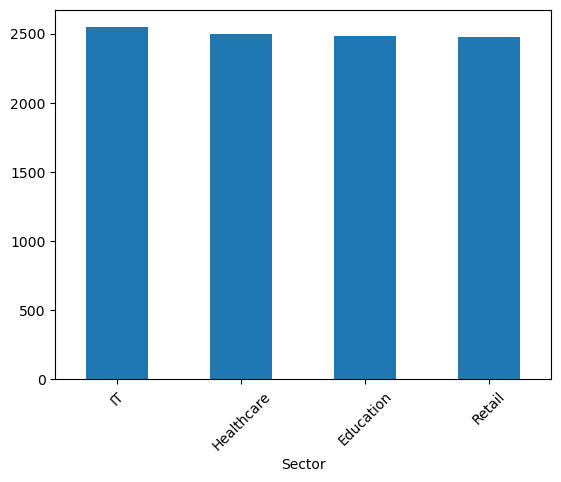

In [9]:
data.Sector.value_counts().plot(kind = 'bar');
plt.xticks(rotation = 45);

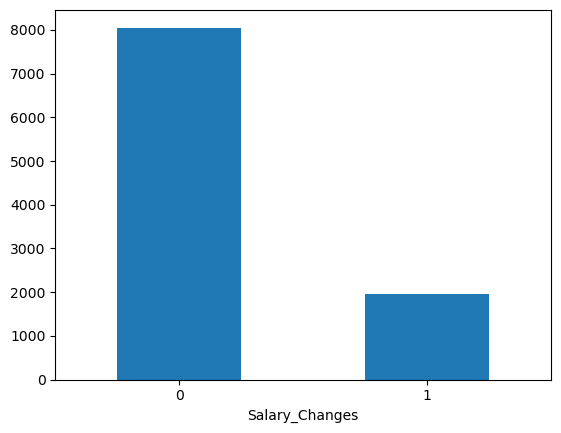

In [10]:
data.Salary_Changes.value_counts().plot(kind = 'bar');
plt.xticks(rotation = 0);

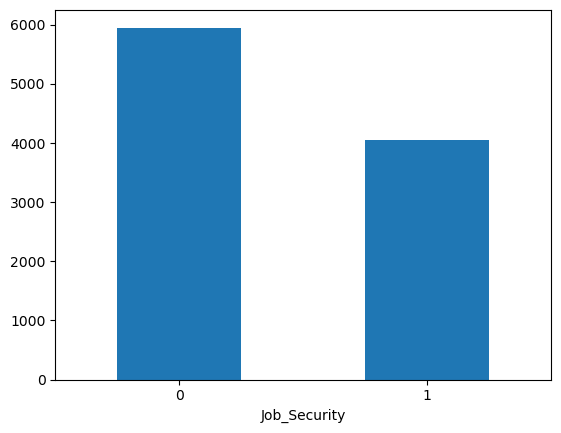

In [11]:
data.Job_Security.value_counts().plot(kind = 'bar');
plt.xticks(rotation = 0);

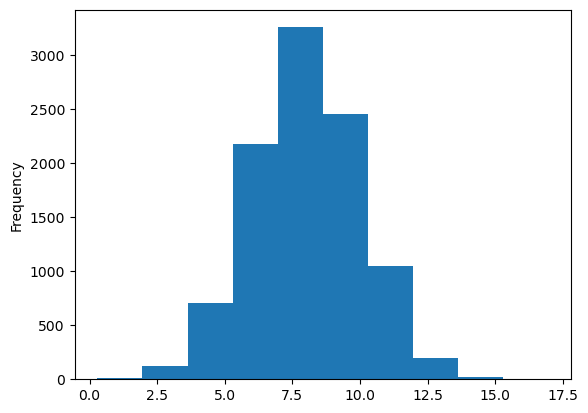

In [12]:
# Ploting the hours worked per day on a histogra
data.Hours_Worked_Per_Day.plot(kind = 'hist');

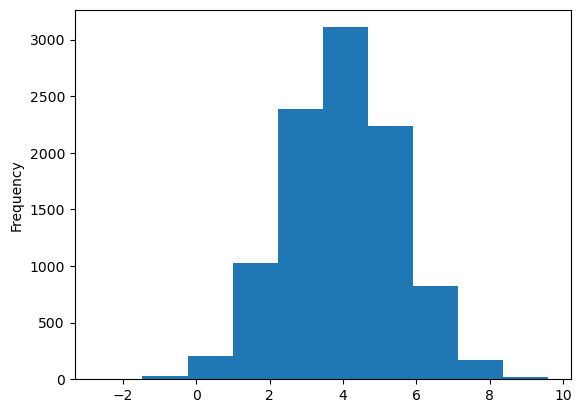

In [13]:
# Ploting the number of virtual meetings 
data.Meetings_Per_Day.plot(kind = 'hist');

In [14]:
pd.crosstab(data.Job_Security, data.Salary_Changes)

Salary_Changes,0,1
Job_Security,,
0,4771,1180
1,3281,768


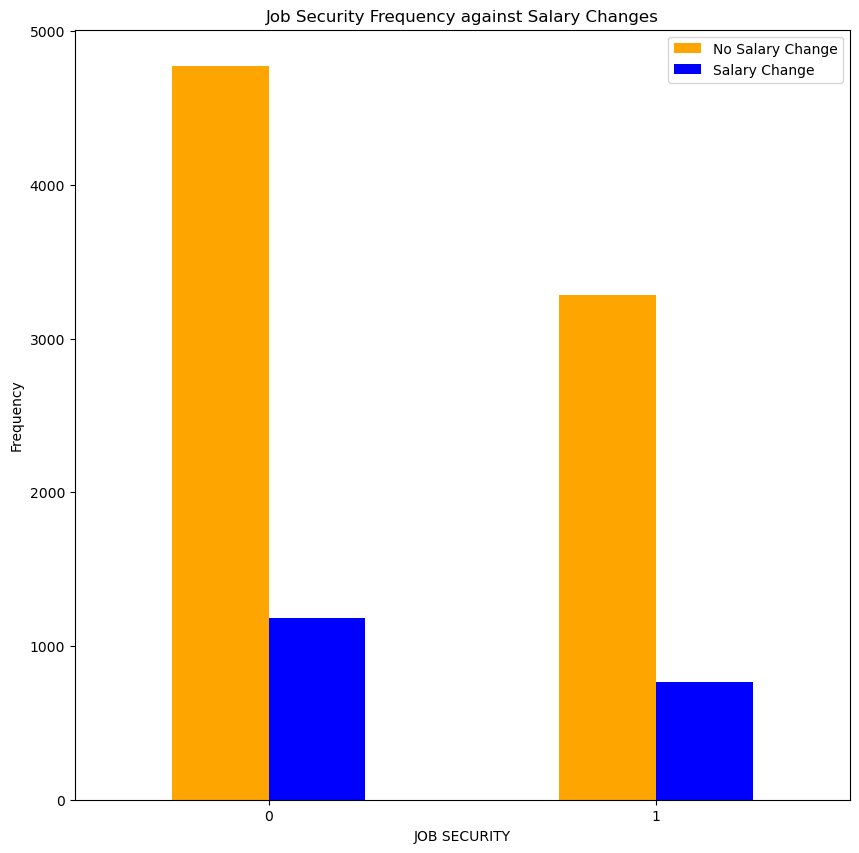

In [15]:
# Create a plot of crosstab
pd.crosstab(data.Job_Security, data.Salary_Changes).plot(kind = "bar",
                                                       figsize = (10, 10),
                                                       color = ['orange', 'blue'])
plt.title("Job Security Frequency against Salary Changes")
plt.xlabel("JOB SECURITY")
plt.ylabel("Frequency")
plt.legend(["No Salary Change", "Salary Change"]);
plt.xticks(rotation = 0);

In [16]:
pd.crosstab(data.Job_Security, data.Health_Issue)

Health_Issue,0,1
Job_Security,,
0,4140,1811
1,2849,1200


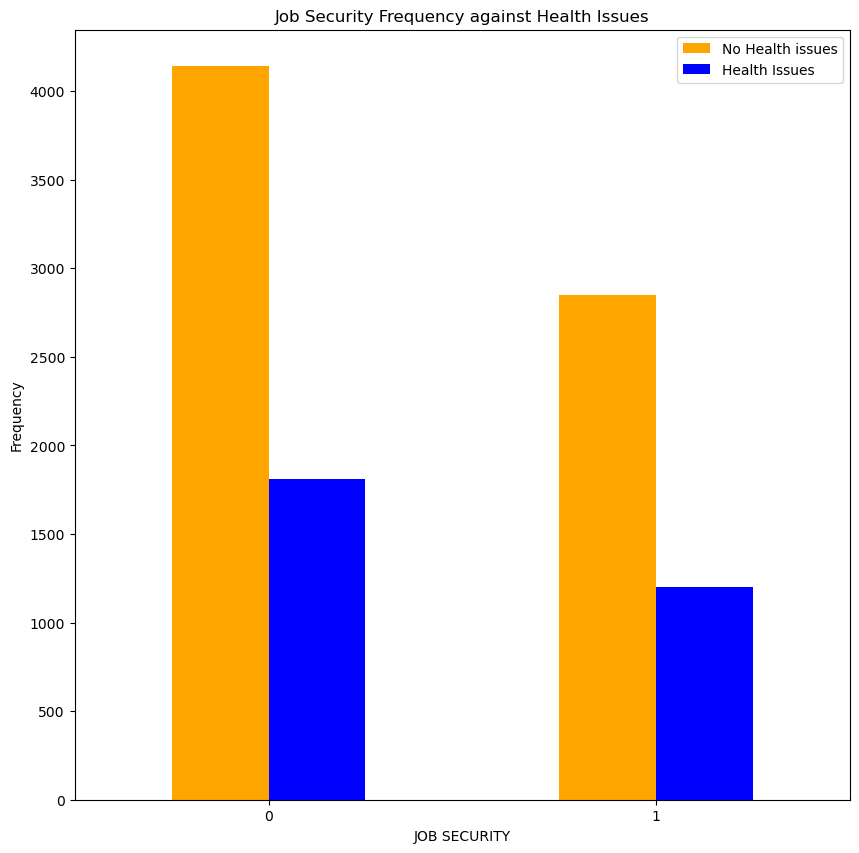

In [17]:
# Create a plot of crosstab
pd.crosstab(data.Job_Security, data.Health_Issue).plot(kind = "bar",
                                                       figsize = (10, 10),
                                                       color = ['orange', 'blue'])
plt.title("Job Security Frequency against Health Issues")
plt.xlabel("JOB SECURITY")
plt.ylabel("Frequency")
plt.legend(["No Health issues", "Health Issues"]);
plt.xticks(rotation = 0);

In [18]:
pd.crosstab(data.Salary_Changes, data.Job_Security)

Job_Security,0,1
Salary_Changes,,
0,4771,3281
1,1180,768


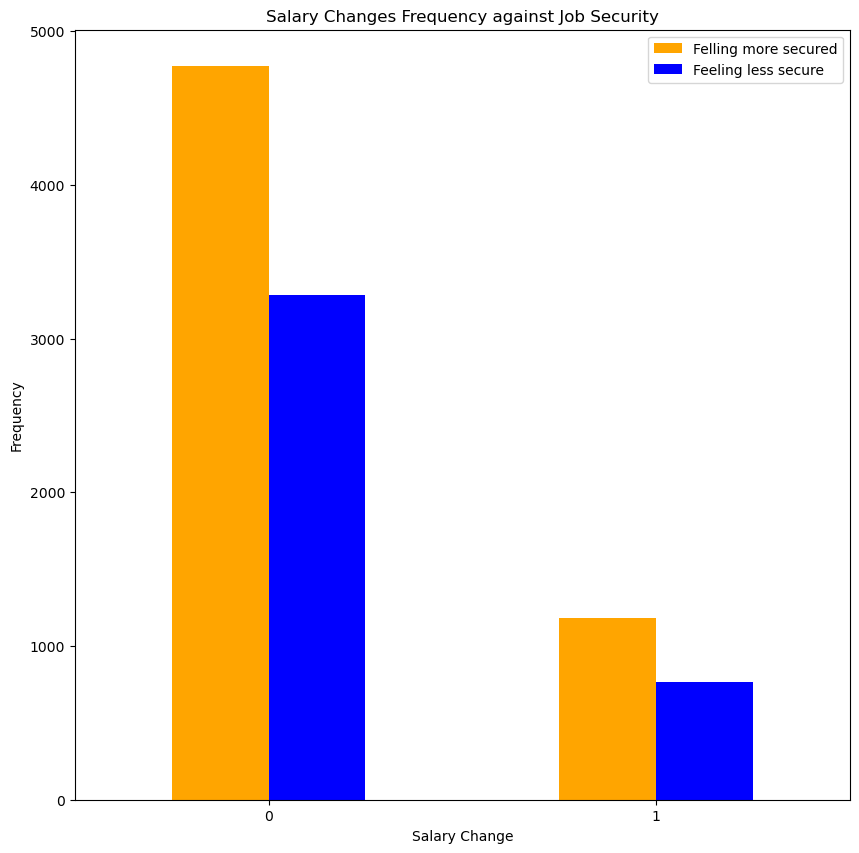

In [19]:
# Create a plot of crosstab
pd.crosstab(data.Salary_Changes, data.Job_Security).plot(kind = "bar",
                                                       figsize = (10, 10),
                                                       color = ['orange', 'blue'])
plt.title("Salary Changes Frequency against Job Security")
plt.xlabel("Salary Change")
plt.ylabel("Frequency")
plt.legend(["Felling more secured", "Feeling less secure"]);
plt.xticks(rotation = 0);

In [20]:
pd.crosstab(data.Job_Security, data.Technology_Adaptation)

Technology_Adaptation,0,1
Job_Security,,
0,2374,3577
1,1575,2474


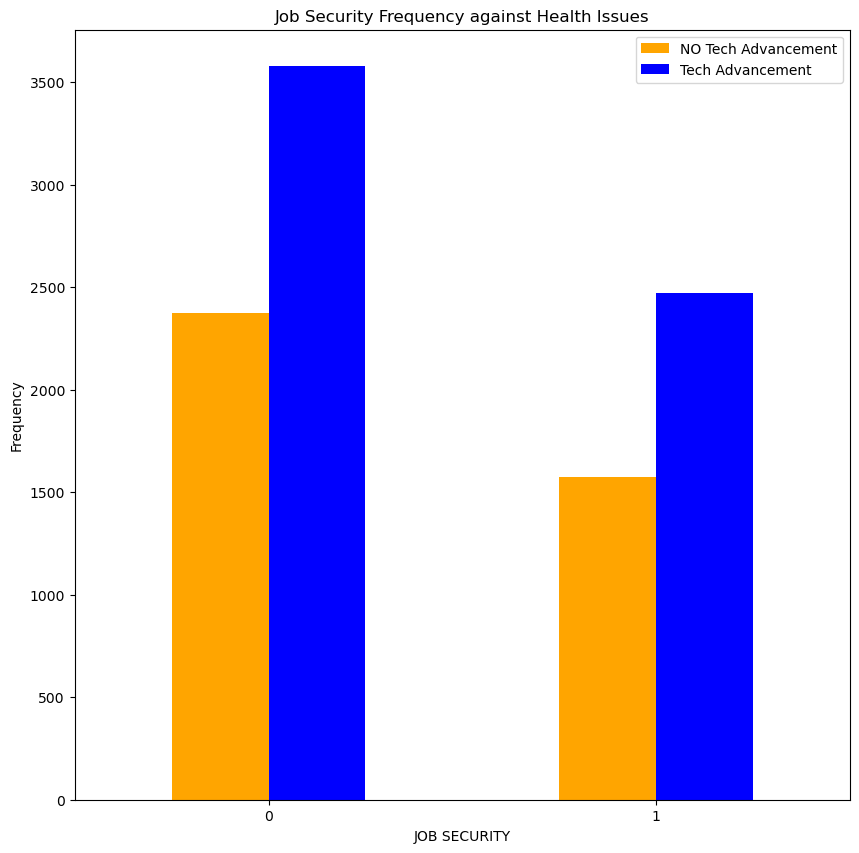

In [21]:
# Create a plot of crosstab
pd.crosstab(data.Job_Security, data.Technology_Adaptation).plot(kind = "bar",
                                                                figsize = (10, 10),
                                                                color = ['orange', 'blue'])
plt.title("Job Security Frequency against Health Issues")
plt.xlabel("JOB SECURITY")
plt.ylabel("Frequency")
plt.legend(["NO Tech Advancement", "Tech Advancement"]);
plt.xticks(rotation = 0);

In [6]:
data_temp = data.copy()

In [6]:
data_temp

,Increased_Work_Hours,Work_From_Home,Hours_Worked_Per_Day,Meetings_Per_Day,Productivity_Change,Stress_Level,Health_Issue,Job_Security,Childcare_Responsibilities,Commuting_Changes,Technology_Adaptation,Salary_Changes,Team_Collaboration_Challenges,Sector,Affected_by_Covid
0,1,1,6.392394,2.684594,1,Low,0,0,1,1,1,0,1,Retail,1
1,1,1,9.171984,3.339225,1,Low,0,1,0,1,1,0,1,IT,1
2,1,0,10.612561,2.218333,0,Medium,0,0,0,0,0,0,0,Retail,1
3,1,1,5.546169,5.150566,0,Medium,0,0,0,1,0,0,0,Education,1
4,0,1,11.424615,3.121126,1,Medium,0,1,1,1,0,1,1,Education,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1,1,7.961822,2.283857,1,Medium,1,1,1,0,0,0,1,IT,1
9996,0,0,10.917086,3.621406,0,Medium,0,0,1,0,1,0,0,IT,1
9997,1,1,10.176211,1.039689,1,Low,0,1,0,1,1,1,1,Retail,1
9998,1,1,11.903973,3.756725,0,Medium,1,1,0,1,1,1,1,Education,1


**Converting the Stress_level column to categories**

In [7]:
# Import label encoder
from sklearn import preprocessing

# Create a label encoder object
label_encoder = preprocessing.LabelEncoder()

# Encode labels in the 'Country' column
data_temp['Stress_Level'] = label_encoder.fit_transform(data_temp['Stress_Level'])
data_temp.head()

,Increased_Work_Hours,Work_From_Home,Hours_Worked_Per_Day,Meetings_Per_Day,Productivity_Change,Stress_Level,Health_Issue,Job_Security,Childcare_Responsibilities,Commuting_Changes,Technology_Adaptation,Salary_Changes,Team_Collaboration_Challenges,Sector,Affected_by_Covid
0,1,1,6.392394,2.684594,1,1,0,0,1,1,1,0,1,Retail,1
1,1,1,9.171984,3.339225,1,1,0,1,0,1,1,0,1,IT,1
2,1,0,10.612561,2.218333,0,2,0,0,0,0,0,0,0,Retail,1
3,1,1,5.546169,5.150566,0,2,0,0,0,1,0,0,0,Education,1
4,0,1,11.424615,3.121126,1,2,0,1,1,1,0,1,1,Education,1


In [8]:
# Converting the Sector columns to categories
data_temp['Sector'] = data_temp['Sector'].astype("category").cat.as_ordered()
data_temp

,Increased_Work_Hours,Work_From_Home,Hours_Worked_Per_Day,Meetings_Per_Day,Productivity_Change,Stress_Level,Health_Issue,Job_Security,Childcare_Responsibilities,Commuting_Changes,Technology_Adaptation,Salary_Changes,Team_Collaboration_Challenges,Sector,Affected_by_Covid
0,1,1,6.392394,2.684594,1,1,0,0,1,1,1,0,1,Retail,1
1,1,1,9.171984,3.339225,1,1,0,1,0,1,1,0,1,IT,1
2,1,0,10.612561,2.218333,0,2,0,0,0,0,0,0,0,Retail,1
3,1,1,5.546169,5.150566,0,2,0,0,0,1,0,0,0,Education,1
4,0,1,11.424615,3.121126,1,2,0,1,1,1,0,1,1,Education,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1,1,7.961822,2.283857,1,2,1,1,1,0,0,0,1,IT,1
9996,0,0,10.917086,3.621406,0,2,0,0,1,0,1,0,0,IT,1
9997,1,1,10.176211,1.039689,1,1,0,1,0,1,1,1,1,Retail,1
9998,1,1,11.903973,3.756725,0,2,1,1,0,1,1,1,1,Education,1


In [9]:
data_temp.Sector.cat.codes

0       3
1       2
2       3
3       0
4       0
       ..
9995    2
9996    2
9997    3
9998    0
9999    3
Length: 10000, dtype: int8

In [10]:
pd.Categorical(data_temp.Sector).codes

array([3, 2, 3, ..., 3, 0, 3], dtype=int8)

In [11]:
data_temp['Sector'] = pd.Categorical(data_temp.Sector).codes

In [12]:
import statsmodels.api as sm

### Calculating VIF

`Variance Inflation Factor(VIF)` is used to detect the severity of multicollinearity in the `Ordinary Least Square (OLS)` regresssion analysis. Multicollinearity inflates the variance and type II error. It makes the coefficient of a variable consistent but unreliable. It essentially measures how much the varinace of a regression coefficient is inflated due to correlations between independent variables in the model; a high `VIF` indicates that a variable is highly correlated with other variables, potentially affecting the reliability of the model's coefficients. A low `VIF` indicates minimal multicollinearity, which is desirable.

In [13]:
# Function to calculate VIF
def calculate_vif(data):
    vif_df = pd.DataFrame(columns = ['Var', 'Vif'])
    x_var_names = data.columns
    for i in range(0, x_var_names.shape[0]):
        y = data[x_var_names[i]]
        x = data[x_var_names.drop([x_var_names[i]])]
        r_squared = sm.OLS(y,x).fit().rsquared
        vif = round(1/(1-r_squared),2)
        vif_df.loc[i] = [x_var_names[i], vif]
    return vif_df.sort_values(by = 'Vif', axis = 0, ascending=False, inplace=False)

X=data_temp.drop(['Job_Security'],axis=1)
calculate_vif(X)

,Var,Vif
13,Affected_by_Covid,41.9
0,Increased_Work_Hours,1.0
1,Work_From_Home,1.0
2,Hours_Worked_Per_Day,1.0
3,Meetings_Per_Day,1.0
4,Productivity_Change,1.0
5,Stress_Level,1.0
6,Health_Issue,1.0
7,Childcare_Responsibilities,1.0
8,Commuting_Changes,1.0


In [14]:
# Check data types
print(X.dtypes)

Increased_Work_Hours               int64
Work_From_Home                     int64
Hours_Worked_Per_Day             float64
Meetings_Per_Day                 float64
Productivity_Change                int64
Stress_Level                       int32
Health_Issue                       int64
Childcare_Responsibilities         int64
Commuting_Changes                  int64
Technology_Adaptation              int64
Salary_Changes                     int64
Team_Collaboration_Challenges      int64
Sector                              int8
Affected_by_Covid                  int64
dtype: object


In [13]:
data_temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Increased_Work_Hours           10000 non-null  int64  
 1   Work_From_Home                 10000 non-null  int64  
 2   Hours_Worked_Per_Day           10000 non-null  float64
 3   Meetings_Per_Day               10000 non-null  float64
 4   Productivity_Change            10000 non-null  int64  
 5   Stress_Level                   10000 non-null  int32  
 6   Health_Issue                   10000 non-null  int64  
 7   Job_Security                   10000 non-null  int64  
 8   Childcare_Responsibilities     10000 non-null  int64  
 9   Commuting_Changes              10000 non-null  int64  
 10  Technology_Adaptation          10000 non-null  int64  
 11  Salary_Changes                 10000 non-null  int64  
 12  Team_Collaboration_Challenges  10000 non-null  

In [15]:
data_temp.corr()

,Increased_Work_Hours,Work_From_Home,Hours_Worked_Per_Day,Meetings_Per_Day,Productivity_Change,Stress_Level,Health_Issue,Job_Security,Childcare_Responsibilities,Commuting_Changes,Technology_Adaptation,Salary_Changes,Team_Collaboration_Challenges,Sector,Affected_by_Covid
Increased_Work_Hours,1.000000,0.005090,-0.014260,-0.007911,0.006247,0.002045,-0.004729,-0.000770,0.004256,0.011807,0.005721,0.014793,-0.016977,0.000660,NaN
Work_From_Home,0.005090,1.000000,-0.018653,-0.017981,0.000416,0.004225,0.007822,0.006375,-0.001384,-0.008640,0.006810,-0.004337,0.009931,-0.007298,NaN
Hours_Worked_Per_Day,-0.014260,-0.018653,1.000000,0.006921,0.013253,-0.001964,0.010649,-0.001083,0.000366,-0.001007,0.009065,0.007990,-0.010025,-0.004118,NaN
Meetings_Per_Day,-0.007911,-0.017981,0.006921,1.000000,0.002971,0.016305,-0.007250,-0.013170,0.015096,-0.006154,-0.009366,0.012184,-0.024114,-0.006414,NaN
Productivity_Change,0.006247,0.000416,0.013253,0.002971,1.000000,0.000865,0.001690,-0.000574,-0.000911,-0.004419,-0.001969,-0.001154,-0.001927,-0.007363,NaN
Stress_Level,0.002045,0.004225,-0.001964,0.016305,0.000865,1.000000,-0.008517,-0.003595,-0.008115,-0.010130,-0.003934,0.002309,0.003963,-0.003922,NaN
Health_Issue,-0.004729,0.007822,0.010649,-0.007250,0.001690,-0.008517,1.000000,-0.008506,-0.002880,-0.003978,0.007601,0.012911,-0.006905,-0.001625,NaN
Job_Security,-0.000770,0.006375,-0.001083,-0.013170,-0.000574,-0.003595,-0.008506,1.000000,0.007396,-0.004648,0.009981,-0.010671,0.010351,0.008424,NaN
Childcare_Responsibilities,0.004256,-0.001384,0.000366,0.015096,-0.000911,-0.008115,-0.002880,0.007396,1.000000,-0.000093,0.017800,0.007344,0.034241,-0.011721,NaN
Commuting_Changes,0.011807,-0.008640,-0.001007,-0.006154,-0.004419,-0.010130,-0.003978,-0.004648,-0.000093,1.000000,-0.010152,-0.003174,-0.014155,-0.008081,NaN


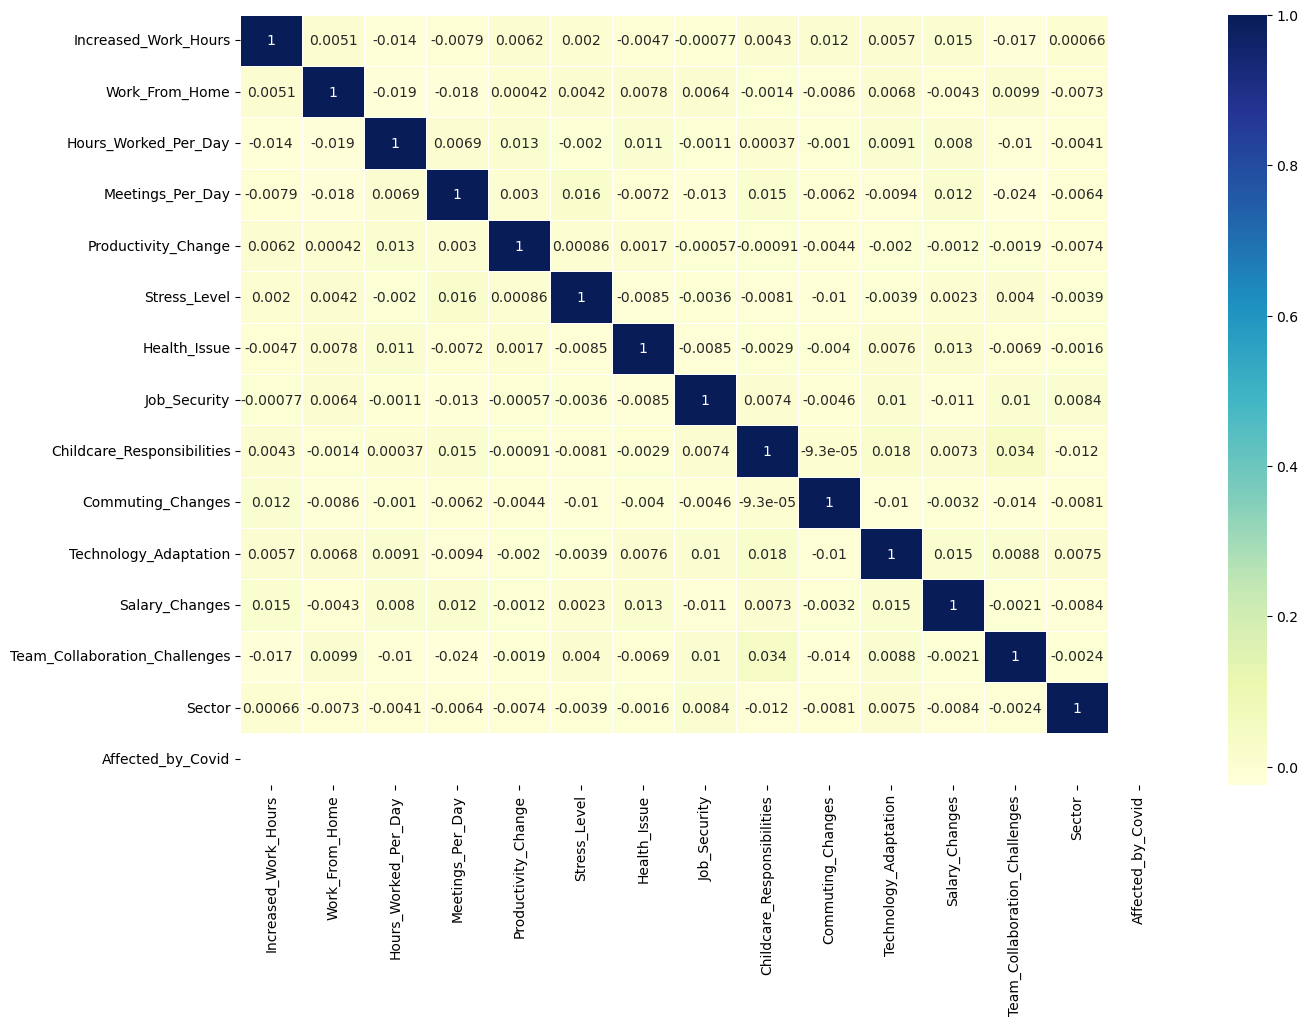

In [16]:
# let's make our correlation matrix a little prettier
corr_matrix = data_temp.corr()
fig, ax = plt.subplots(figsize = (15, 10))
ax = sns.heatmap(corr_matrix,
                 annot = True,
                 linewidths = 0.5,
                 # fmt = ".2f",
                 cmap = "YlGnBu"); # YlGnBu = Yellow Green Blue

## Modelling 

In [16]:
data_temp

,Increased_Work_Hours,Work_From_Home,Hours_Worked_Per_Day,Meetings_Per_Day,Productivity_Change,Stress_Level,Health_Issue,Job_Security,Childcare_Responsibilities,Commuting_Changes,Technology_Adaptation,Salary_Changes,Team_Collaboration_Challenges,Sector,Affected_by_Covid
0,1,1,6.392394,2.684594,1,1,0,0,1,1,1,0,1,3,1
1,1,1,9.171984,3.339225,1,1,0,1,0,1,1,0,1,2,1
2,1,0,10.612561,2.218333,0,2,0,0,0,0,0,0,0,3,1
3,1,1,5.546169,5.150566,0,2,0,0,0,1,0,0,0,0,1
4,0,1,11.424615,3.121126,1,2,0,1,1,1,0,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1,1,7.961822,2.283857,1,2,1,1,1,0,0,0,1,2,1
9996,0,0,10.917086,3.621406,0,2,0,0,1,0,1,0,0,2,1
9997,1,1,10.176211,1.039689,1,1,0,1,0,1,1,1,1,3,1
9998,1,1,11.903973,3.756725,0,2,1,1,0,1,1,1,1,0,1


In [17]:
x = data_temp.drop('Job_Security', axis = 1)
y = data_temp.Job_Security

In [18]:
x

,Increased_Work_Hours,Work_From_Home,Hours_Worked_Per_Day,Meetings_Per_Day,Productivity_Change,Stress_Level,Health_Issue,Childcare_Responsibilities,Commuting_Changes,Technology_Adaptation,Salary_Changes,Team_Collaboration_Challenges,Sector,Affected_by_Covid
0,1,1,6.392394,2.684594,1,1,0,1,1,1,0,1,3,1
1,1,1,9.171984,3.339225,1,1,0,0,1,1,0,1,2,1
2,1,0,10.612561,2.218333,0,2,0,0,0,0,0,0,3,1
3,1,1,5.546169,5.150566,0,2,0,0,1,0,0,0,0,1
4,0,1,11.424615,3.121126,1,2,0,1,1,0,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1,1,7.961822,2.283857,1,2,1,1,0,0,0,1,2,1
9996,0,0,10.917086,3.621406,0,2,0,1,0,1,0,0,2,1
9997,1,1,10.176211,1.039689,1,1,0,0,1,1,1,1,3,1
9998,1,1,11.903973,3.756725,0,2,1,0,1,1,1,1,0,1


In [19]:
y

0       0
1       1
2       0
3       0
4       1
       ..
9995    1
9996    0
9997    1
9998    1
9999    0
Name: Job_Security, Length: 10000, dtype: int64

In [18]:
# Split our data into train and test sets
np.random.seed(42)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)

...

Now we've got our data split into training and test sets, it's time to build a machine learning model.

We'll train it (find the patterns) on the training set.

And we'll test it (use the patterns) on the test set

We're going to try 3 different machine learning models:
1. Logistic Regression
2. K-Nearest Neighbours classifiers
3. Random Forest Classifier
4. Linear SVC
5. SVC

In [19]:
%%time
# Put models in a dictionary
models = {"Logistic Regression": LogisticRegression(),
          "KNN": KNeighborsClassifier(),
          "Random Forest": RandomForestClassifier(),
          "LinearSVC": LinearSVC(),
          "SVC": SVC()}

# Create a function to fit and score models
def fit_and_score(models, x_train, x_test, y_train, y_test):
    """
    Fits and evaluates given machine learning models.
    models : a dict of different scikit-learn machine learning models
    x_train : training data (no labels)
    x_test : testing data (no labels)
    y_train : training labels 
    y_test : test labels
    """
    
    # Set random seed
    np.random.seed(42)
    
    # Make dictionary to keep model scores
    model_scores = {}
    
    # LOOP through models
    for name, model in models.items():
        # Fit the model to the data
        model.fit(x_train, y_train)
        # Evaluate the model and append its score to the model_scores
        model_scores[name] = model.score(x_test, y_test)
    
    return model_scores


CPU times: total: 0 ns
Wall time: 999 μs


In [20]:
%%time
model_scores = fit_and_score(models = models,
                             x_train = x_train,
                             x_test = x_test,
                             y_train = y_train,
                             y_test = y_test)
model_scores

CPU times: total: 25.3 s
Wall time: 30.1 s


{'Logistic Regression': 0.5785,
 'KNN': 0.545,
 'Random Forest': 0.544,
 'LinearSVC': 0.5785,
 'SVC': 0.5785}

....

>This project gives a poor performance with the dataset, with each model accuracy withing the 50% basically making our models Guess. This could be as a result of the fact that people feeling insecure about their jobs doesn't necessaritly mean that their job is not secured. That said we will try to predict if there will be a salary revision.

The model will predict whether or not an employee got a change in their pay, whether positive, pay increase or negative, pay deduction


# SALARY REVISION


Due to the fact that the model gave a poor performance on the dataset, the problem definition changed to suit a more solvable problem inline with the dataset. The dataset gave poor outcome to the previous problem due to its lack of richness in solving that problem and the vagueness of the problem in terms of the dataset. 


## NEW PROBLEM DEFINITION
This project aims at implementing various machine learning techniques to predict the if a person's salary will be reviewed in line with performance, post covid activities, etc.

In [21]:
X=data_temp.drop(['Salary_Changes'],axis=1)
calculate_vif(X)

,Var,Vif
13,Affected_by_Covid,42.42
0,Increased_Work_Hours,1.00
1,Work_From_Home,1.00
2,Hours_Worked_Per_Day,1.00
3,Meetings_Per_Day,1.00
4,Productivity_Change,1.00
5,Stress_Level,1.00
6,Health_Issue,1.00
7,Job_Security,1.00
8,Childcare_Responsibilities,1.00


In [22]:
data_temp

,Increased_Work_Hours,Work_From_Home,Hours_Worked_Per_Day,Meetings_Per_Day,Productivity_Change,Stress_Level,Health_Issue,Job_Security,Childcare_Responsibilities,Commuting_Changes,Technology_Adaptation,Salary_Changes,Team_Collaboration_Challenges,Sector,Affected_by_Covid
0,1,1,6.392394,2.684594,1,1,0,0,1,1,1,0,1,3,1
1,1,1,9.171984,3.339225,1,1,0,1,0,1,1,0,1,2,1
2,1,0,10.612561,2.218333,0,2,0,0,0,0,0,0,0,3,1
3,1,1,5.546169,5.150566,0,2,0,0,0,1,0,0,0,0,1
4,0,1,11.424615,3.121126,1,2,0,1,1,1,0,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1,1,7.961822,2.283857,1,2,1,1,1,0,0,0,1,2,1
9996,0,0,10.917086,3.621406,0,2,0,0,1,0,1,0,0,2,1
9997,1,1,10.176211,1.039689,1,1,0,1,0,1,1,1,1,3,1
9998,1,1,11.903973,3.756725,0,2,1,1,0,1,1,1,1,0,1


In [22]:
x = data_temp.drop('Salary_Changes', axis = 1)
y = data_temp.Salary_Changes

In [23]:
np.random.seed(42)
x_train_1, x_test_1, y_train_1, y_test_1 = train_test_split(x, y, test_size = 0.2)

In [24]:
%%time
model_scores = fit_and_score(models = models,
                             x_train = x_train_1,
                             x_test = x_test_1,
                             y_train = y_train_1,
                             y_test = y_test_1)
model_scores

CPU times: total: 14.4 s
Wall time: 16.4 s


{'Logistic Regression': 0.8025,
 'KNN': 0.768,
 'Random Forest': 0.798,
 'LinearSVC': 0.8025,
 'SVC': 0.8025}

....

>Our models perform better with predicting salary change from the same data set than they can did predicting Job security

In [49]:
np.random.seed(42)
log_reg = LogisticRegression()
log_reg.fit(x_train_1, y_train_1)

LogisticRegression()

In [50]:
log_reg.score(x_test_1, y_test_1)

0.8025

In [51]:
y_preds = log_reg.predict(x_test_1)
y_preds

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [52]:
print(classification_report(y_test_1, y_preds))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1605
           1       0.00      0.00      0.00       395

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.45      2000
weighted avg       0.64      0.80      0.71      2000



C:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


>Even though our models perform well and have high accuracy they perform pooorly in terms of other metrics and this is because there is an imbalance of class in the dataset thereby making our model to overfit

In [23]:
data_temp.Salary_Changes.value_counts()

Salary_Changes
0    8052
1    1948
Name: count, dtype: int64

## SALARY CHANGE augmentation

The classes in the Salary change column are inbalanced with class 0 having a total of 8052 and class 1 having a total of 1948. Which will affect our models ability to predict properly on class 1. AS such we will perform class balancing by randomly creating new values for class 0 with our already existing values.

In [25]:
count_0, count_1 = data_temp['Salary_Changes'].value_counts()

df_count_0, df_count_1 = data_temp[data_temp['Salary_Changes'] == 0], data_temp[data_temp['Salary_Changes'] == 1]

count_1, count_0

(1948, 8052)

In [26]:
data_count_1 = df_count_1.sample(count_0, replace = True)

In [27]:
data_temp_2 = pd.concat([df_count_0, data_count_1])

In [28]:
data_temp_2['Salary_Changes'].value_counts()

Salary_Changes
0    8052
1    8052
Name: count, dtype: int64

In [29]:
x = data_temp_2.drop('Salary_Changes', axis = 1)
y = data_temp_2.Salary_Changes

In [30]:
np.random.seed(42)
x_train_2, x_test_2, y_train_2, y_test_2 = train_test_split(x, y, test_size = 0.2)

In [64]:
np.random.seed(42)
Log_Reg = LogisticRegression()
Log_Reg.fit(x_train_2, y_train_2)

LogisticRegression()

In [65]:
Log_Reg.score(x_test_2, y_test_2)

0.5156783607575287

In [31]:
model_scores_2 = fit_and_score(models = models,
                             x_train = x_train_2,
                             x_test = x_test_2,
                             y_train = y_train_2,
                             y_test = y_test_2)
model_scores_2

{'Logistic Regression': 0.5159888233467868,
 'KNN': 0.7056814653834212,
 'Random Forest': 0.9481527475939149,
 'LinearSVC': 0.5162992859360447,
 'SVC': 0.5197143744178826}

> The only model which did significantly better with the augmentation is our RandomForest model.

In [34]:
np.random.seed(42)
KNN_model = KNeighborsClassifier()
KNN_model.fit(x_train_2, y_train_2)

KNeighborsClassifier()

In [35]:
KNN_model.score(x_test_2, y_test_2)

0.6938838869916175

In [32]:
np.random.seed(42)
clf = RandomForestClassifier()
clf.fit(x_train_2, y_train_2)

RandomForestClassifier()

In [33]:
clf.score(x_test_2, y_test_2)

0.9481527475939149

In [34]:
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [39]:
np.random.seed(42)
model_1 = LinearSVC()
model_1.fit(x_train_2, y_train_2)

LinearSVC()

In [40]:
model_1.score(x_test_2, y_test_2)

0.5085377212045948

In [41]:
np.random.seed(42)
model_2 = SVC()
model_2.fit(x_train_2, y_train_2)

SVC()

In [42]:
model_2.score(x_test_2, y_test_2)

0.5104004967401428

In [35]:
y_preds_2 = clf.predict(x_test_2)
y_preds_2

array([0, 0, 1, ..., 1, 1, 0], dtype=int64)

In [36]:
print(classification_report(y_test_2, y_preds_2))

              precision    recall  f1-score   support

           0       0.96      0.93      0.95      1569
           1       0.94      0.96      0.95      1652

    accuracy                           0.95      3221
   macro avg       0.95      0.95      0.95      3221
weighted avg       0.95      0.95      0.95      3221



>After balancing the datasets and all our other models declined in accuracy but our Ensemble model performed the best giving an accuracy of over 90% and even on the other metrics it performed great. Now we will try to improve on our Ensemble method.

### Ensemble model Hyperparameter tuning

In [37]:
# Create a hyperparameter grid for RandomForestCLassifier
rf_grid = {"n_estimators": np.arange(50, 1200, 50),
           "max_depth": [None, 3, 5, 10],
           "min_samples_split": np.arange(2, 10, 1),
           "min_samples_leaf": np.arange(1, 10, 1),
           "max_features" : [0.5, 1, "sqrt", "log2"]
          }

In [80]:
# Instantiate RandomizedSearchCV model
rs_model = RandomizedSearchCV(RandomForestClassifier(n_jobs = -1,
                                                    random_state = 42),
                             param_distributions = rf_grid,
                             n_iter = 200,
                             cv = 5,
                             verbose = True)

# Fit the RandomizedSearchCV model
rs_model.fit(x_train_2, y_train_2)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
                   n_iter=200,
                   param_distributions={'max_depth': [None, 3, 5, 10],
                                        'max_features': [0.5, 1, 'sqrt',
                                                         'log2'],
                                        'max_samples': [5000],
                                        'min_samples_leaf': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                                        'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14, 16, 18]),
                                        'n_estimators': array([ 10,  60, 110, 160, 210, 260, 310, 360, 410, 460, 510, 560, 610,
       660, 710, 760, 810, 860, 910, 960])},
                   verbose=True)

In [81]:
 rs_model.best_params_

{'n_estimators': 460,
 'min_samples_split': 2,
 'min_samples_leaf': 3,
 'max_samples': 5000,
 'max_features': 0.5,
 'max_depth': None}

In [82]:
rs_model.score(x_test_2, y_test_2)

0.8727103384042223

>The accuracy of our RandomizedSearchCV model fell below that of our baseline model so we will engage in more tuning using GridSearchCV

In [88]:
%%time
# Set up the tuning parameters of GridSearchCV
ideal_model =  GridSearchCV(RandomForestClassifier(),
                           param_grid = rf_grid,
                           cv = 3,
                           verbose = True,
                           n_jobs = -1)
# Fit the modle
ideal_model.fit(x_train_2, y_train_2)

Fitting 3 folds for each of 12960 candidates, totalling 38880 fits


KeyboardInterrupt: 

In [38]:
from joblib import parallel_backend

In [39]:
from tqdm.notebook import tqdm
import time

In [40]:
tqdm.pandas()

In [41]:
# Instantiate RandomizedSearchCV model
rsModel = RandomizedSearchCV(RandomForestClassifier(random_state = 42),
                             param_distributions = rf_grid,
                             n_iter = 1000,
                             cv = 3,
                             verbose = 2)

In [42]:
%%time
# Fit the RandomizedSearchCV model
rsModel.fit(x_train_2, y_train_2)

Fitting 3 folds for each of 1000 candidates, totalling 3000 fits
[CV] END max_depth=5, max_features=1, min_samples_leaf=8, min_samples_split=8, n_estimators=800; total time=  18.0s
[CV] END max_depth=5, max_features=1, min_samples_leaf=8, min_samples_split=8, n_estimators=800; total time=  19.0s
[CV] END max_depth=5, max_features=1, min_samples_leaf=8, min_samples_split=8, n_estimators=800; total time=   8.3s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=350; total time=  11.3s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=350; total time=  17.7s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=350; total time=  19.7s
[CV] END max_depth=10, max_features=0.5, min_samples_leaf=7, min_samples_split=3, n_estimators=900; total time=  39.0s
[CV] END max_depth=10, max_features=0.5, min_samples_leaf=7, min_samples_split=3, n_estimators=900; to

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   n_iter=1000,
                   param_distributions={'max_depth': [None, 3, 5, 10],
                                        'max_features': [0.5, 1, 'sqrt',
                                                         'log2'],
                                        'min_samples_leaf': array([1, 2, 3, 4, 5, 6, 7, 8, 9]),
                                        'min_samples_split': array([2, 3, 4, 5, 6, 7, 8, 9]),
                                        'n_estimators': array([  50,  100,  150,  200,  250,  300,  350,  400,  450,  500,  550,
        600,  650,  700,  750,  800,  850,  900,  950, 1000, 1050, 1100,
       1150])},
                   verbose=2)

In [43]:
rsModel.best_params_

{'n_estimators': 1050,
 'min_samples_split': 4,
 'min_samples_leaf': 1,
 'max_features': 'log2',
 'max_depth': None}

In [44]:
best_model = rsModel.best_estimator_
best_model

RandomForestClassifier(max_features='log2', min_samples_split=4,
                       n_estimators=1050, random_state=42)

In [45]:
best_model.score(x_test_2, y_test_2)

0.9500155231294629

>We'd be using the results of our hyperparameter tuning to create a new model.

In [47]:
np.random.seed(42)
modle = RandomForestClassifier(n_estimators = 1050,
                               min_samples_split = 4,
                               min_samples_leaf = 1,
                               max_features = 'log2',
                               max_depth = None)
modle

RandomForestClassifier(max_features='log2', min_samples_split=4,
                       n_estimators=1050)

In [48]:
np.random.seed(42)
modle.fit(x_train_2, y_train_2)

RandomForestClassifier(max_features='log2', min_samples_split=4,
                       n_estimators=1050)

In [49]:
np.random.seed(42)
modle.score(x_test_2, y_test_2)

0.9500155231294629

In [50]:
np.random.seed(42)
y_preds = modle.predict(x_test_2)
y_preds

array([0, 0, 1, ..., 1, 1, 0], dtype=int64)

## Evaluating our tuned machine learning classifier, beyond accuracy

We'd be using the following evaluation methods to evaluate our models
* ROC curve and AUC score
* Confusion matrix
* Classification report
* Precision
* Recall
* F1-score


### Plot ROC curve and calculate AUC metric score

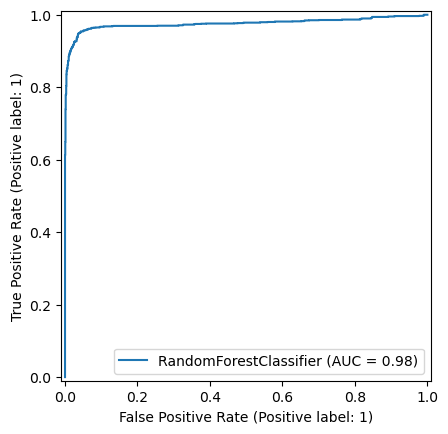

In [51]:
# Plot ROC curve and calculate and calculate AUC metric

RocCurveDisplay.from_estimator(estimator = modle, 
                               X = x_test_2, 
                               y = y_test_2);

### PLOT Confusion Matrix

In [52]:
# Confusion matridx
print(confusion_matrix(y_test_2, y_preds))

[[1479   90]
 [  71 1581]]


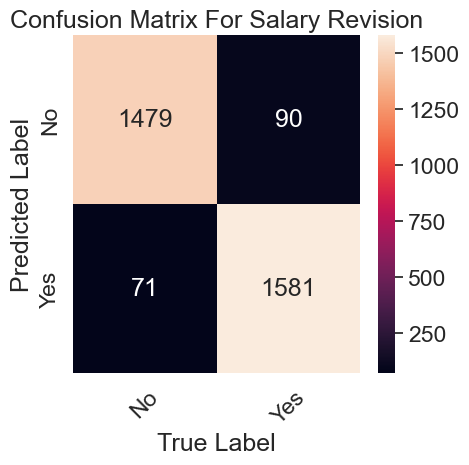

In [72]:
# Display your confusion matrix

sns.set(font_scale = 1.5)

labels = ['No', 'Yes']  # Class 0 = 'No' and Class 1 = 'Yes'

def plot_conf_mat(y_test, y_preds):
    """
    Plots a nice looking confusion matrix using Seaborn's heatmap()
    """
    fig, ax = plt.subplots(figsize = (5, 5))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                     annot = True,
                     fmt = "d",
                     cbar = True,
                     xticklabels = labels,
                     yticklabels = labels)
    plt.xlabel("True Label")
    plt.ylabel("Predicted Label")
    plt.title("Confusion Matrix For Salary Revision")
    plt.xticks(rotation = 45)
    plt.tight_layout()
    plt.show();
    
plot_conf_mat(y_test_2, y_preds)

### Classification Report

A classification report is basically the perfomance summary of the classification model, showing how well the model has performed for each class, using key metrics like precision, recall, f1-score and support.

In [54]:
print(classification_report(y_test_2, y_preds))

              precision    recall  f1-score   support

           0       0.95      0.94      0.95      1569
           1       0.95      0.96      0.95      1652

    accuracy                           0.95      3221
   macro avg       0.95      0.95      0.95      3221
weighted avg       0.95      0.95      0.95      3221



### Calculate Evaluation metrics using cross-validation

Next phase will be to calculate precision, recall and f1-score of the best fit model using cross-validation, `cross_val_score`.

**`Precision`**: Of all predicted positives, how many were correct?
> This matters in cases where the goal is to avoid false positives. i.e. High precision = fewer wrong "Yes" prediction 

**`Recal`**: Of all actual positives, how many did the model catch?
>This matters in cases where the goal is to avoid false negatives. i.e. High Recall = fewer missed "Yes" cases

**`F1-Score`**: It is a harmonic mean of precision and recal
>This matters in cases where both Precision and Recall are needed. It helps keep track of a great balance between both.

**`Support`**: Number of instances of the classes in the data. This is used in the classification report above
>It shows how many examples our metrics are based on

This metrics help diagnose imbalance between classes, so we can treat if need be.

In [56]:
Clf = RandomForestClassifier(n_estimators = 1050,
                             min_samples_split = 4,
                             min_samples_leaf = 1,
                             max_features = 'log2',
                             max_depth = None)
Clf

RandomForestClassifier(max_features='log2', min_samples_split=4,
                       n_estimators=1050)

In [57]:
# Cross-validated accuracy
cv_acc = cross_val_score(Clf,
                         x,
                         y,
                         cv = 5,
                         scoring = "accuracy")
cv_acc

array([0.94256442, 0.94908414, 0.95560385, 0.95063645, 0.94503106])

In [58]:
mean_cv_acc = np.mean(cv_acc)
mean_cv_acc

0.9485839820587334

In [59]:
# Cross-validated precision
cv_prec = cross_val_score(Clf,
                          x,
                          y,
                          scoring = "precision")
cv_prec

array([0.93562232, 0.9430496 , 0.9490172 , 0.94539877, 0.94386181])

In [61]:
mean_cv_prec = np.mean(cv_prec)
mean_cv_prec

0.9433899410549469

In [62]:
# Cross-validated Recall
cv_rec = cross_val_score(Clf,
                         x,
                         y,
                         scoring = "recall")
cv_rec

array([0.94720497, 0.95652174, 0.96027312, 0.95530726, 0.94906832])

In [63]:
mean_cv_rec = np.mean(cv_rec)
mean_cv_rec

0.9536750831820056

In [64]:
# Cross-validated f1-score
cv_f1 = cross_val_score(Clf,
                        x,
                        y,
                        scoring = "f1")
cv_f1

array([0.94425624, 0.94896381, 0.95496607, 0.95367511, 0.94313968])

In [65]:
mean_cv_f1 = np.mean(cv_f1)
mean_cv_f1

0.9490001808524212

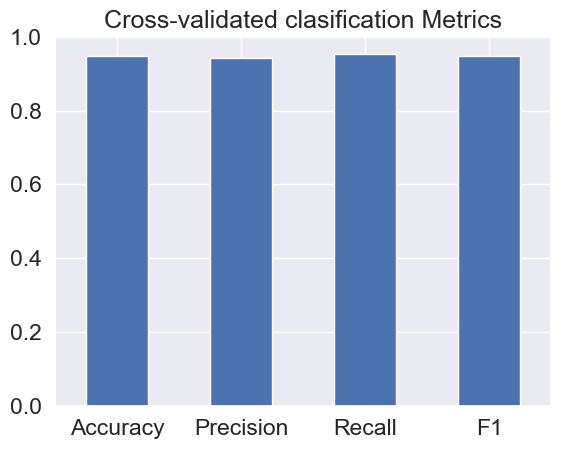

In [66]:
cv_metrics = pd.DataFrame({"Accuracy" : mean_cv_acc,
                           "Precision" : mean_cv_prec,
                           "Recall" : mean_cv_rec,
                           "F1": mean_cv_f1},
                          index = [0])

cv_metrics.T.plot.bar(title = "Cross-validated clasification Metrics",
                      legend = False)
plt.xticks(rotation = 0);

## Feature Importance

Feature importance is another way of asking; 

> "which features contributed most to the outcomes of the model and how did they contribute".

Finding feature importance is different for each machine learning model.

Let's find the feature importance for our Ensemble model...

In [67]:
# Create a new classifier with the same parameters from hyperparameter tuning
Clfr = RandomForestClassifier(n_estimators = 1050,
                              min_samples_split = 4,
                              min_samples_leaf = 1,
                              max_features = 'log2',
                              max_depth = None,
                              random_state = 42)
Clfr

RandomForestClassifier(max_features='log2', min_samples_split=4,
                       n_estimators=1050, random_state=42)

In [68]:
np.random.seed(42)
Clfr.fit(x_train_2, y_train_2)

RandomForestClassifier(max_features='log2', min_samples_split=4,
                       n_estimators=1050, random_state=42)

In [69]:
Clfr.feature_importances_

array([0.02597251, 0.02473169, 0.30848238, 0.30678198, 0.03209386,
       0.05298307, 0.02738263, 0.03161711, 0.02731148, 0.03079842,
       0.02419254, 0.02871718, 0.07893517, 0.        ])

In [70]:
# Match the importances of features to columns
feature_dict = dict(zip(x.columns, Clfr.feature_importances_))
feature_dict

{'Increased_Work_Hours': 0.025972512217592777,
 'Work_From_Home': 0.02473168611725199,
 'Hours_Worked_Per_Day': 0.30848237526058636,
 'Meetings_Per_Day': 0.30678197934210427,
 'Productivity_Change': 0.03209385531845555,
 'Stress_Level': 0.052983066914665276,
 'Health_Issue': 0.027382630574685197,
 'Job_Security': 0.03161711130641848,
 'Childcare_Responsibilities': 0.027311475476476856,
 'Commuting_Changes': 0.030798417502497854,
 'Technology_Adaptation': 0.024192537904664867,
 'Team_Collaboration_Challenges': 0.02871717801155462,
 'Sector': 0.07893517405304593,
 'Affected_by_Covid': 0.0}

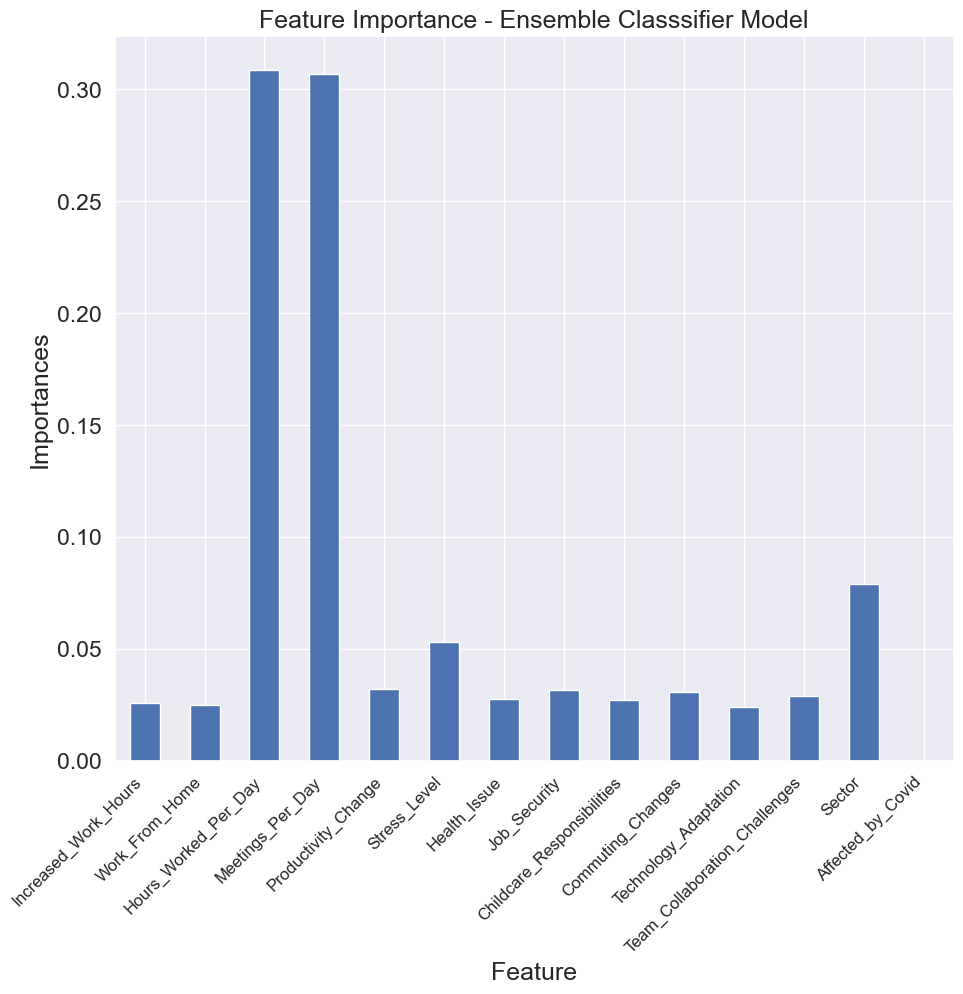

In [71]:
# Visualize feature importance
feature_df = pd.DataFrame(feature_dict , index = [0])
feature_df.T.plot.bar(figsize = (10,10), title = "Feature Importance - Ensemble Classsifier Model", legend = False);
plt.xticks(rotation = 45, ha = "right", fontsize = 12) # ha = horizontal alignment, right aligned
plt.tight_layout()
plt.xlabel("Feature")
plt.ylabel("Importances");

### Saving Model

Saving our loaded model using `PICKLE` module

In [73]:
import pickle

# Save an existing model to file
pickle.dump(Clfr, open("Salary_revision_ensemble_clf_model.pkl", "wb"))

Saving our fitted model using the `JOBLIB` module

In [74]:
from joblib import dump, load

# Save model to file
dump(Clfr, filename = "Salary_revision_ensemble_clf_model.joblib")

['Salary_revision_ensemble_clf_model.joblib']